<a href="https://colab.research.google.com/github/tsinviking/semantic-safety-gateway/blob/main/Exploration_into_Semantic_Caching_and_Safety_Gateways.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Blueprint for Production: Exploration into Semantic Caching and Safety Gateways**

#**Overview**

[Lenovo](https://www.lenovo.com/us/en/solutions/cioplaybook2026/?orgRef=https%253A%252F%252Fwww.google.com%252F) reported that 50%-54% of AI proofs of concept fail to reach production. The stall in prototype phase mostly happen due to challenges with realiability, escalating inference costs, and edge cases. My experience in LLMs applications itself has been mostly in PoC, this is my attempt to dive deeper into the required infrastructure for AI agents.


---


The first question that comes to my mind is how can we build a deterministic safety web around a non-deterministic intelligence without killing the user experience? To answer these, I decided to step away from high-level application wrappers and build a low-level experimental infrastructure pipeline.





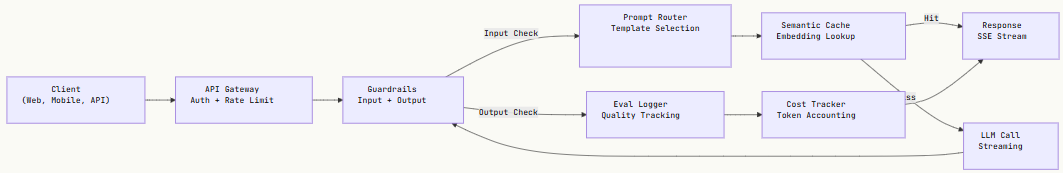

*source: AI Engineering from scratch*

As seen in AIEFS's LLM application flow, required structures in production environment are mostly the same. The details may vary, but not the flow.

The request enters through an API gateway that handles authentication and rate limiting. Then, the request will go through several processes that may happen sequentially and/or parallelly:
1. Context management
2. Guardrails management
3. Evaluation & Cost Tracker

#**1. Context Management**

For every request, we need to manage the context window. A context window is basically like the whole book that is needed by the model to generate output, that also includes blank pages in the book for the book to write. So, a context window consists of:
- system instructions
- retrieved documents
- tool definitions (if any)
- conversation history
- few-shot examples (if any, can improve the model's output)
- the user's prompt
- generation budget (tokens needed for the model to write its output)

LLMs have limited input tokens. Even when they accept up to 1M tokens, it has been reported that models have a tendency to ignore the middle context. Hence,  managing the order of critical information inside the context window is importnat.

This becomes challenging because a production chatbot often wears many hats. For instance, an e-commerce assistant might need to answer FAQs accurately, handle complex customer service issues, or use the persuasive tactics of a skilled floor salesman. Each capability requires a completely different skill set which means handling a completely different set of system prompts.

The structural important was further proven in a 2023 study by Liu et al. They demonstrated the "lost in the middle" phenomenon by hiding a single relevant document at various positions within a stack of 20 irrelevant ones. The researchers found that an LLM's ability to recall information follows a sharp U-shaped curve: the model successfully answered questions with 85–90% accuracy when the crucial document was placed at the very beginning or the very end of the context window. However, accuracy plummeted to 60–70% when that same information was buried center at position 10.

Faced with this, the question becomes dual-headed:

- How do we dynamically inject the right behavioral prompt depending on the query's intent?

- How do we simultaneously ensure that the core system identity (persona, brand behavior, safety constraints) stays consistent across a single user session?

To solve this, I can think of two pathways:

- **Intent Routing**: classifying a user's intent to select and inject only the relevant prompt capsule. This routing mechanism can also act as a filter for active tool selection, targeted vector memory retrieval, and more.

- **Persistent System Mapping**: a structural layer that anchors a constant, general system prompt to a specific user's session ID.

For this specific run of the experiment, I focused on validating the session-persistence layer—ensuring that a user receives a single, constant system prompt per session, while also setting up the foundations required to run A/B evaluations on different prompt styles.

In [ ]:
#config file

import os
from enum import Enum
from dotenv import load_dotenv

load_dotenv()

class ModelName(Enum):
    LLAMA_3_3_70B = "llama-3.3-70b-versatile"
    LLAMA_3_1_8B  = "llama-3.1-8b-instant"
    MIXTRAL_8X7B  = "mixtral-8x7b-32768"


MODEL_PRICING = {
    ModelName.LLAMA_3_3_70B: {"input": 0.59, "output": 0.79},
    ModelName.LLAMA_3_1_8B:  {"input": 0.05, "output": 0.08},
    ModelName.MIXTRAL_8X7B:  {"input": 0.24, "output": 0.24},
}

FALLBACK_CHAIN = [
    ModelName.LLAMA_3_3_70B,
    ModelName.LLAMA_3_1_8B,
    ModelName.MIXTRAL_8X7B
]

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
IS_MOCK_MODE = False

In [ ]:
# cache file
import hashlib
import time
from collections import defaultdict
from typing import Dict, Any, Optional

import numpy as np
import redis.asyncio as aioredis
from redis.commands.search.field import TextField, VectorField
from redis.commands.search.index_definition import IndexDefinition, IndexType
from redis.commands.search.query import Query
from sentence_transformers import SentenceTransformer

from config import ModelName, MODEL_PRICING

# ============================================================================
# 1. Thread-Isolated Embedding Setup
# ============================================================================
print("Loading sentence-transformers embedding framework...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
EMBEDDING_DIM = 384
INDEX_NAME = "semantic_cache"


# ============================================================================
# 2. Redis Vector Cache Engine (Async-Native)
# ============================================================================
class RedisSemanticCache:
    def __init__(self, redis_url: str = "redis://localhost:6379", distance_threshold: float = 0.14, ttl_seconds: int = 3600):
        """
        For COSINE distance metrics in Redis VSS:
        - 0.0 is an identical match.
        - Distance values below 0.14-0.16 generally represent close semantic matches.
        """
        self.redis_url = redis_url
        self.threshold = distance_threshold
        self.ttl = ttl_seconds
        self.pool = aioredis.ConnectionPool.from_url(redis_url, decode_responses=True)
        self.client = aioredis.Redis(connection_pool=self.pool)
        self.hits = 0
        self.misses = 0

    async def initialize_index(self):
        """Creates the VSS Index using raw search fields if it does not exist."""
        try:
            await self.client.ft(INDEX_NAME).info()
            print("Redis vector semantic index detected.")
        except Exception:
            schema = (
                TextField("prompt"),
                TextField("response"),
                VectorField(
                    "embedding",
                    "FLAT",
                    {
                        "TYPE": "FLOAT32",
                        "DIM": EMBEDDING_DIM,
                        "DISTANCE_METRIC": "COSINE",
                    },
                ),
            )
            # Index hashes beginning with 'cache:'
            await self.client.ft(INDEX_NAME).create_index(
                fields=schema,
                definition=IndexDefinition(prefix=["cache:"], index_type=IndexType.HASH),
            )
            print("Successfully initialized fresh Redis VSS index mappings.")

    def _get_embedding(self, text: str) -> bytes:
        """Encodes string to raw FLOAT32 vector bytes using sentence-transformers."""
        return embedding_model.encode(text).astype(np.float32).tobytes()

    async def get(self, query: str) -> Optional[Dict[str, Any]]:
        """Queries Redis Vector Space using Async K-Nearest Neighbors."""
        query_vector = self._get_embedding(query)

        # Redis Vector Search syntax: Find 1 nearest neighbor
        base_query = "*=>[KNN 1 @embedding $vec_param AS vector_distance]"
        q = (
            Query(base_query)
            .return_fields("prompt", "response", "vector_distance")
            .sort_by("vector_distance")
            .paging(0, 1)
            .dialect(2)
        )

        try:
            results = await self.client.ft(INDEX_NAME).search(q, query_params={"vec_param": query_vector})
            if results.docs:
                match = results.docs[0]
                distance = float(match.vector_distance)

                if distance <= self.threshold:
                    self.hits += 1
                    # Invert distance back to a standard user-facing similarity score
                    similarity = round(1.0 - distance, 4)
                    return {
                        "response": match.response,
                        "similarity": similarity
                    }
        except Exception as e:
            print(f"Cache lookup anomaly suppressed: {e}")

        self.misses += 1
        return None

    async def put(self, query: str, response: str):
        """Persists the payload deterministically with an active system TTL."""
        digest = hashlib.md5(query.encode()).hexdigest()
        doc_id = f"cache:{digest}"

        mapping = {
            "prompt": query,
            "response": response,
            "embedding": self._get_embedding(query)
        }

        # Execute pipeline non-blockingly via async context managers
        async with self.client.pipeline(transaction=True) as pipe:
            pipe.hset(doc_id, mapping=mapping)
            pipe.expire(doc_id, self.ttl)
            await pipe.execute()


# ============================================================================
# 3. Cost Accounting Telemetry Tracker
# ============================================================================
class CostTracker:
    def __init__(self):
        self.total_requests = 0
        self.total_cost_usd = 0.0
        self.cost_by_user = defaultdict(float)

    def record(self, user_id: str, model_enum: ModelName, input_t: int, output_t: int):
        pricing = MODEL_PRICING.get(model_enum, {"input": 0.0, "output": 0.0})
        cost = ((input_t / 1_000_000) * pricing["input"]) + ((output_t / 1_000_000) * pricing["output"])

        self.total_requests += 1
        self.total_cost_usd += cost
        self.cost_by_user[user_id] += cost
        return cost

    def get_summary(self) -> Dict[str, Any]:
        return {
            "total_requests": self.total_requests,
            "total_cost_usd": round(self.total_cost_usd, 6),
            "top_users": dict(sorted(self.cost_by_user.items(), key=lambda x: x[1], reverse=True)[:5])
        }

In [ ]:
#engine file
import json
import random
import asyncio
import hashlib
from typing import AsyncGenerator, Dict, Any, Tuple
from groq import AsyncGroq, GroqError
from dataclasses import dataclass
from config import ModelName, FALLBACK_CHAIN, GROQ_API_KEY, IS_MOCK_MODE

@dataclass
class PromptTemplate:
    name: str
    version: str
    template: str
    model: ModelName = ModelName.LLAMA_3_3_70B
    max_output_tokens: int = 1024


PROMPT_TEMPLATES = {
    "general_chat": {
        "v1": PromptTemplate(
            name="general_chat",
            version="v1",
            template=(
                "You are a helpful AI assistant. Answer the user's question clearly and concisely.\n\n"
                "User question: {query}"
            ),
        ),
        "v2": PromptTemplate(
            name="general_chat",
            version="v2",
            template=(
                "You are an AI assistant that gives precise, actionable answers. "
                "If you are unsure, say so. Never fabricate information.\n\n"
                "Question: {query}\n\nAnswer:"
            ),
        ),
    },
    "rag_answer": {
        "v1": PromptTemplate(
            name="rag_answer",
            version="v1",
            template=(
                "Answer the question using ONLY the provided context. "
                "If the context does not contain the answer, say 'I don't have enough information.'\n\n"
                "Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"
            ),
            max_output_tokens=512,
        ),
    },
    "code_review": {
        "v1": PromptTemplate(
            name="code_review",
            version="v1",
            template=(
                "You are a senior software engineer performing a code review. "
                "Identify bugs, security issues, and performance problems. "
                "Be specific. Reference line numbers.\n\n"
                "Code:\n```\n{code}\n```\n\nReview:"
            ),
            model=ModelName.LLAMA_3_3_70B,
            max_output_tokens=2048,
        ),
    },
}


AB_EXPERIMENTS = {
    "general_chat_v2_test": {
        "template": "general_chat",
        "control": "v1",
        "variant": "v2",
        "traffic_pct": 10,
    },
}


def select_prompt(template_name, user_id, variables):
    versions = PROMPT_TEMPLATES.get(template_name)
    if not versions:
        raise ValueError(f"Unknown template: {template_name}")

    version = "v1"
    for exp_name, exp in AB_EXPERIMENTS.items():
        if exp["template"] == template_name:
            bucket = int(hashlib.md5(f"{user_id}:{exp_name}".encode()).hexdigest(), 16) % 100
            if bucket < exp["traffic_pct"]:
                version = exp["variant"]
            else:
                version = exp["control"]
            break

    template = versions.get(version, versions["v1"])
    rendered = template.template.format(**variables)
    return template, rendered

class LLMEngine:
    def __init__(self):
        # Instantiate the thread-safe Async Groq client
        self.client = AsyncGroq(api_key=GROQ_API_KEY)

    async def stream_chat(
        self,
        system_prompt: str,
        user_prompt: str,
        preferred_model: ModelName
    ) -> AsyncGenerator[str, None]:
        """
        Executes a streaming request against Groq. Automatically captures 429/500
        exceptions and transparently rolls over to fallback models in the chain.
        """
        # Build local adaptive fallback loop chain matching priority settings
        chain = list(FALLBACK_CHAIN)
        if preferred_model in chain:
            chain.remove(preferred_model)
            chain.insert(0, preferred_model)

        for current_model in chain:
            try:
                if IS_MOCK_MODE:
                    yield json.dumps({
                        "type": "meta",
                        "model": current_model.value,
                        "input_tokens": 12, "output_tokens": 24
                    })
                    yield json.dumps({"type": "token", "text": "Mock token streaming validation..."})
                    yield json.dumps({"type": "done", "final_text": "Mock token streaming validation..."})
                    return

                # Establish streaming runtime payload connection
                stream = await self.client.chat.completions.create(
                    model=current_model.value,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    temperature=0.2,
                    stream=True
                )

                accumulated_text = []
                async for chunk in stream:
                    # Capture real-time usage data if supplied inline by provider chunk
                    if hasattr(chunk, 'usage') and chunk.usage:
                        yield json.dumps({
                            "type": "meta",
                            "model": current_model.value,
                            "input_tokens": chunk.usage.prompt_tokens,
                            "output_tokens": chunk.usage.completion_tokens
                        })

                    delta = chunk.choices[0].delta.content if chunk.choices else ""
                    if delta:
                        accumulated_text.append(delta)
                        yield json.dumps({"type": "token", "text": delta})

                # Terminate stream cleanly and pass data up for cache ingestion
                yield json.dumps({
                    "type": "done",
                    "final_text": "".join(accumulated_text)
                })
                return

            except (GroqError, Exception) as e:
                # Log or suppress failure internally to execute subsequent fallback models silently
                print(f"Warning: Model failure on {current_model.value}. Advancing fallback. Err: {e}")
                continue

        # Critical circuit break failure state
        yield json.dumps({
            "type": "error",
            "message": "Critical: Model failover pool entirely exhausted."
        })

I want to highlight 3 systems in this experiment:
1. Fallback Plans
2. A/B Testing Setup with Prompts
3. Log Tracker

### **1.1. Fallback Plans**

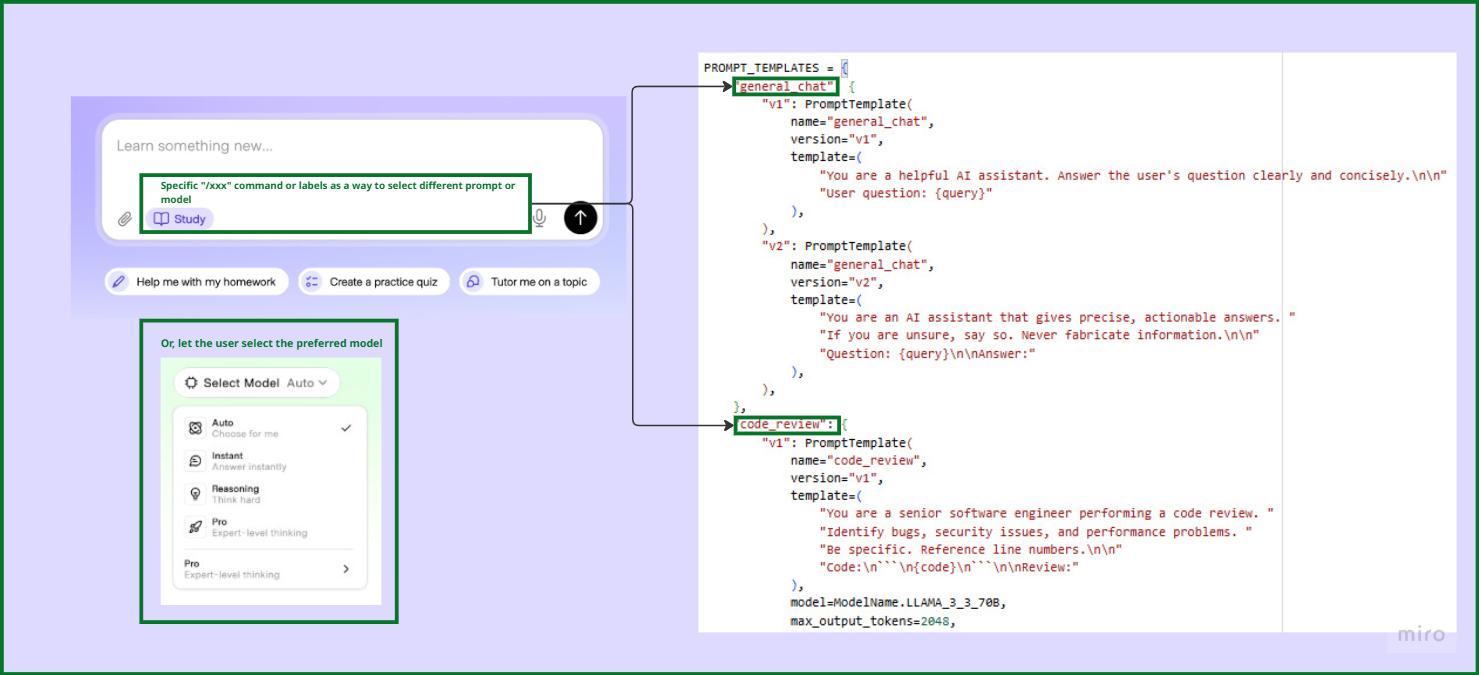

The models chain here is adjusted to available models by Groq.


> FALLBACK_CHAIN = [
    ModelName.LLAMA_3_3_70B,
    ModelName.LLAMA_3_1_8B,
    ModelName.MIXTRAL_8X7B
]


If we encounter an issue with the first chosen model, we can retry the prompt with the next model to ensure that user receives an output. From user's perspective, user only sees an output without knowing which model triggers it. We rely heavily on Groq here, so if there is an issue with Groq inference itself-- then it is sort of game over. In real production, we can use different providers as the fallback chain like Anthropic, OpenAI, or Gemini. We can also set the very last chain to be a static text so that user still receives a response. I think it is better that way than waiting for a response and only receives an error.

Combining model chain with intent routing, I think we can also adjust the selected model depending on the identified intent by the user. For instance, if we notice that user wants to brainstorm, we can use a more powerful reasoning model.

### **1.2. A/B Testing Setup with Prompts**

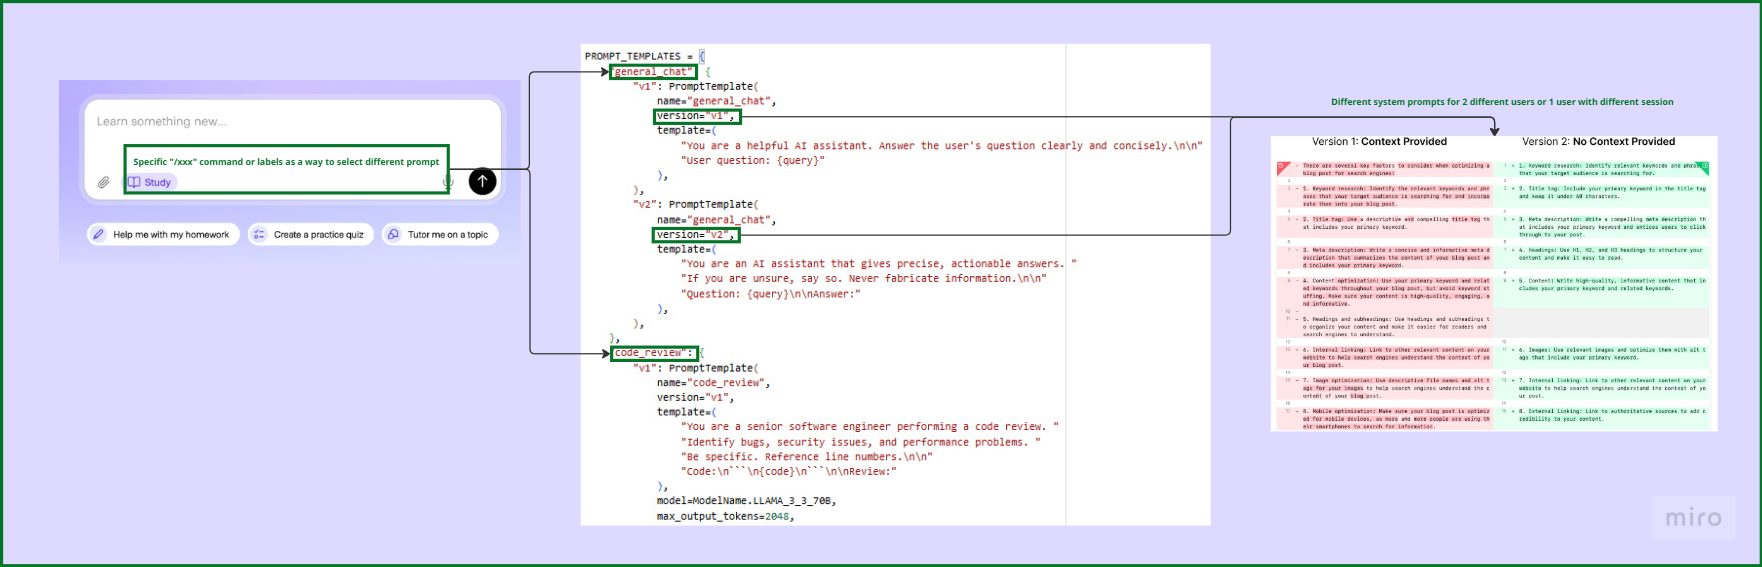

There are 2 types of prompts for the general_chat experiment. Though, the prompts are not that different in this experiment. The goal is to show the required setup for A/B test. When a user initiates a session, there will be a user ID and the experiment type. As long as both variables stay the same, we will turn these variables into hash and convert them into a number between 0 and 99. The number will stay the same for 1 user throughout the experiment and the session. We will use the number to define the  prompt that the user will receive. In this case, if the number is less than 10, then user will receive the variant prompt.

In the above image, /command mechanism is better described as prompt routing rather than part of A/B testing. I am just showing you different mechanisms to switch a prompt in production.

### **1.3. Log Tracker**

Though token price has dropped, it doesn't mean that the overall cost of LLM-powered apps will drop. User's expectation of certain capability may require us to use more tokens, like the underlying prompts & retrieved contexts etc of reasoning or agentic behavior capabilities.

So, token monitoring is needed. The setup of this monitor is by looking at the usage attribute of chunks from Groq which we categorize as meta json. In later code, we will look for the meta type and capture it in our token usage / cost tracker.

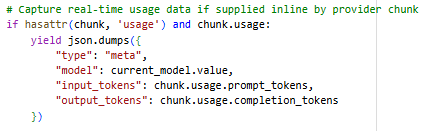

# **2. Guardrails Management**

Guardrails is used to protect LLM-powered apps from sharing information to bad actors. I think it is especially harmful when the LLM-powered apps share informations like user's data or exclusive company data to outsiders. It also works both ways, when the output of the app is harmful in terms of language selection or advices that can lead to LLM psychosis. In production, we need to filter both the input and the output.

Input guardrails include things like topic classification, prompt injection detection, PII detection, or overly-lengthy user prompt & rate limit of chat usage per user.

Output guardrail include things like toxic words filtering, PII scrubbing, hallucination detection or even format validation if user asks for certain format.

In this experiment, we utilize regex to identify certain patterns we know. Though, there can be more complex implementation for guardrails management. I am still learning about the multi-turns guardrails management (instead of asking LLM to share information in 1 bubble chat, the user "traps" the LLM-powered apps to share the information in multiple chats). My guess is on detection being run for the whole chats after n-turns or maybe sliding-window.

In [ ]:
#guardrails file

import re
from dataclasses import dataclass
from typing import Optional

INJECTION_PATTERNS = [
    r"ignore\s+(all\s+)?previous\s+instructions",
    r"system\s*:\s*override",
    r"you\s+are\s+now\s+dan",
    r"jailbreak",
]

PII_PATTERNS = {
    "ssn": r"\b\d{3}-\d{2}-\d{4}\b",
    "credit_card": r"\b\d{4}[\s-]?\d{4}[\s-]?\d{4}[\s-]?\d{4}\b",
    "email": r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b"
}

BANNED_OUTPUT_PATTERNS = [
    r"(?i)(DROP|DELETE|TRUNCATE)\s+TABLE",
    r"(?i)rm\s+-rf\s+/",
]

@dataclass
class GuardrailResult:
    passed: bool
    blocked_reason: Optional[str] = None
    modified_text: Optional[str] = None

def validate_input(text: str) -> GuardrailResult:
    for pattern in INJECTION_PATTERNS:
        if re.search(pattern, text, re.IGNORECASE):
            return GuardrailResult(passed=False, blocked_reason="")

    modified=text
    pii_found = False

    for pii_type, pattern in PII_PATTERNS.items():
        if re.search(pattern, modified):
            pii_found = True
            modified = re.sub(pattern, f"[REDACTED_{pii_type.upper()}]", modified)

    return GuardrailResult(passed=True, modified_text=modified if pii_found else None)

def validate_output(text: str) -> GuardrailResult:
    for pattern in BANNED_OUTPUT_PATTERNS:
        if re.search(pattern,text):
            return GuardrailResult(passed=False, blocked_reason="Destructive command sequence found in generation.")
        return GuardrailResult(passed=True)


# **3. Evaluation & Cost Tracker**

We have created the pieces that we need, it's time to set up the elements into 1 pipeline to process user query. I call this orchestrator, I think people have different terms on this. Essentially, it is about connecting the different pieces to set up the flow that we want.

In [ ]:
# the orchestrator file or main file

import json
from contextlib import asynccontextmanager
from fastapi import FastAPI, HTTPException
from fastapi.responses import StreamingResponse
from pydantic import BaseModel, Field

# Import all custom modular components
from config import ModelName
from engine import LLMEngine, select_prompt
from cache import RedisSemanticCache, CostTracker
from guardrails import validate_input, validate_output

# ============================================================================
# FastAPI Lifespan (Startup / Shutdown Management)
# ============================================================================
# Instantiate shared singleton infrastructure instances
cost_tracker = CostTracker()
llm_engine = LLMEngine()

# Instantiate Redis Semantic Cache with a distance threshold and 1-hour TTL
semantic_cache = RedisSemanticCache(
    redis_url="redis://localhost:6379",
    distance_threshold=0.3,
    ttl_seconds=3600
)

@asynccontextmanager
async def lifespan(app: FastAPI):
    # This block executes exactly once when web application boots up
    await semantic_cache.initialize_index()
    yield
    # Clean teardown when server processes exit
    await semantic_cache.client.close()

app = FastAPI(title="Production-Grade Resilient Groq Gateway", version="2.0.0", lifespan=lifespan)

# ============================================================================
# Pydantic Request/Response Payload Validations
# ============================================================================
class ChatRequest(BaseModel):
    user_id: str = Field(..., example="usr_dev_99", description="Unique identifier for user session routing and A/B tracking.")
    template_name: str = Field(default="general_chat", example="general_chat", description="The registered layout prompt target mapping.")
    variables: dict = Field(..., example={"query": "Explain quantum computing simply"}, description="Key-value tokens injected directly into prompt layout arrays.")
    preferred_model: ModelName = Field(default=ModelName.LLAMA_3_3_70B, description="The primary requested model execution target.")

class MetricsSummary(BaseModel):
    total_requests: int
    total_cost_usd: float
    top_users: dict

# ============================================================================
# Gateway Orchestration Generator Pipeline
# ============================================================================
async def request_orchestration_pipeline(payload: ChatRequest):
    """
    Asynchronous state machine managing the lifecycle of an LLM execution flow:
    Guardrails -> Cache Interception -> Engine Execution -> Output Evaluation -> Ingestion.
    """
    user_id = payload.user_id
    variables = payload.variables
    preferred_model = payload.preferred_model

    # Extract the fundamental core question out of the input variables dictionary
    raw_query = variables.get("query", variables.get("code", ""))

    # 1. RUN INPUT GUARDRAILS
    if not validate_input(raw_query):
        yield json.dumps({"type": "error", "message": "Security Alert: Input violated safety guardrail policies."})
        return

    # 2. INTERCEPT VIA REDIS SEMANTIC CACHE (Now awaitable and async)
    cache_hit = await semantic_cache.get(raw_query)
    if cache_hit:
        yield json.dumps({
            "type": "meta",
            "model": f"CACHE_HIT (Sim: {cache_hit['similarity']})",
            "input_tokens": 0, "output_tokens": 0
        })
        yield json.dumps({"type": "token", "text": cache_hit["response"]})
        yield json.dumps({"type": "done", "final_text": cache_hit["response"]})
        return

    # 3. SELECT AND RENDER A/B PROMPT VARIANT
    try:
        prompt_template, rendered_user_prompt = select_prompt(payload.template_name, user_id, variables)
    except Exception as e:
        yield json.dumps({"type": "error", "message": f"Prompt Generation Error: {str(e)}"})
        return

    target_model = preferred_model if preferred_model else prompt_template.model
    system_instruction = "You are a secure, high-performance production enterprise AI utility."

    # 4. INITIALIZE CHAT STREAM ENGINE LOOP WITH FALLBACK RESILIENCE
    actual_model_used = target_model.value
    input_tokens_used = 0
    output_tokens_used = 0
    accumulated_response_text = ""

    async for chunk in llm_engine.stream_chat(system_instruction, rendered_user_prompt, target_model):
        data = json.loads(chunk)
        packet_type = data.get("type")

        if packet_type == "meta":
            actual_model_used = data.get("model")
            input_tokens_used = data.get("input_tokens", 0)
            output_tokens_used = data.get("output_tokens", 0)
            yield chunk

        elif packet_type == "token":
            accumulated_response_text += data.get("text", "")
            yield chunk

        elif packet_type == "done":
            # 5. RUN OUTPUT GUARDRAILS
            if not validate_output(accumulated_response_text):
                yield json.dumps({"type": "error", "message": "Security Alert: Generated text violated output quality policies."})
                return

            # 6. INGEST RESPONSE INTO REDIS SEMANTIC CACHE MATRIX (Now awaitable and async)
            await semantic_cache.put(raw_query, accumulated_response_text)

            # 7. COMMIT ACCOUNTING METRICS TRANSACTIONS TO TELEMETRY STORAGE
            try:
                model_enum = ModelName(actual_model_used)
                cost_tracker.record(user_id, model_enum, input_tokens_used, output_tokens_used)
            except Exception:
                cost_tracker.record(user_id, target_model, input_tokens_used, output_tokens_used)

            yield chunk

        elif packet_type == "error":
            yield chunk

# ============================================================================
# API Endpoint Controller Handlers
# ============================================================================
@app.post("/v1/chat/stream")
async def chat_stream_endpoint(payload: ChatRequest):
    """
    Primary API gateway endpoint. Wraps our asynchronous orchestration lifecycle
    pipeline inside a streaming text/event-stream HTTP connection block.
    """
    return StreamingResponse(
        request_orchestration_pipeline(payload),
        media_type="text/event-stream"
    )

@app.get("/v1/telemetry/costs", response_model=MetricsSummary)
async def get_cost_metrics():
    """
    Retrieves operational cost summaries, request totals, and top resource usage aggregations.
    """
    return cost_tracker.get_summary()

> semantic_cache = RedisSemanticCache(
    redis_url="redis://localhost:6379",
    distance_threshold=0.3,
    ttl_seconds=3600
)

In the context management section, I mentioned briefly about conversation history. The implication of the "lost-in-the-middle" findings is that conversation itself needs to be maintained in terms of order and importance. There are many strategies to manage this. But, how about managing it before it ever enters the context window itself? that's the function of semantic caching here, we check if the query user shared has been asked before. If yes, then we just use the recorded answer. We can't do this for the whole day, else it will be memory problem on our side. We need to set up a certain time range to capture all these queries and responses.

I set up the time (called Time-to-Live in Redis) to 1 hour which means that we will do similarity checking of a new query with recorded embedded queries in the past 1 hour. I set up the similarity distance by 30%, meaning 70% matched. At first, I set it up by 15%. After certain experiments, it turns out that 85% match is a bit hard for 2 similar sentences with minimum shared words between the two. I found 30% is the right distance here.


In the orchestrator pipeline, the first checkpoint will be the input validation to check if there is violation to the guardrails we have set up. Then, we will check if the query has a match hit with with the semantic cache. If there is, we will use the response recorded in the cache. If not, then we will trigger A/B testing mechanism to choose the right prompt & hit llm_engine with stream_chat.

As long as packet type done is not received, we will collect each token response or the usage information. Once we receive "done" packet type, we will run the output guardrails validation, put the new query and response to semantic cache, and calculate the used tokens & potential cost.

# **Test**

In the test set, we have 3 scenarios:
1. A new query to a new redis semantic cache-- expecting cache miss
In this scenario, we will ask the following question: How do vectors work in software engineering? You can see that we stream each token chunk in the picture

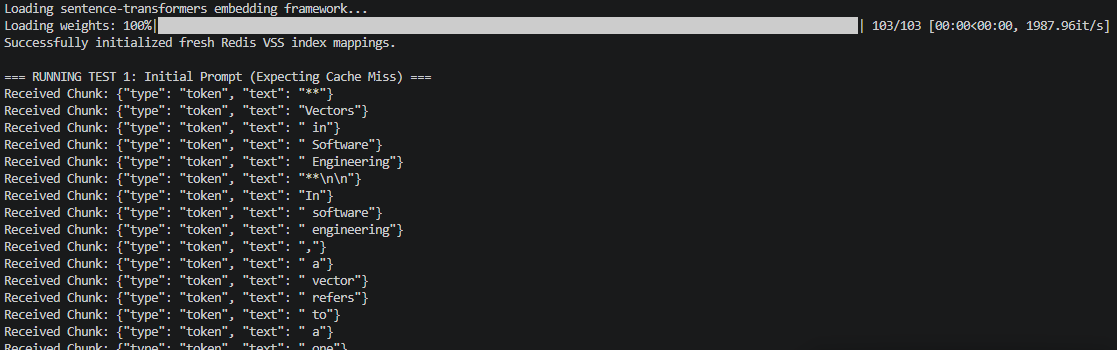

The response to the query is as follows. 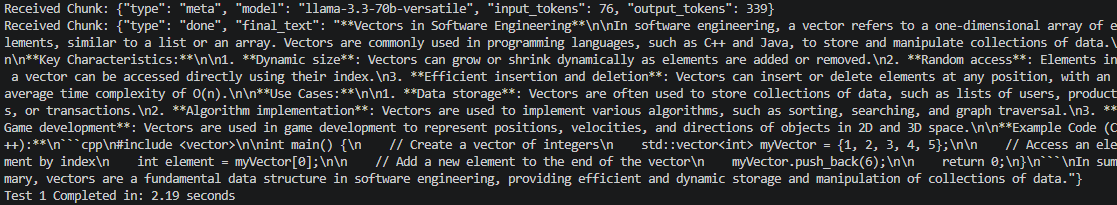

2. A similar query to scenario 1-- expecting cache hit.
The question in this scenario is "Can you explain how vectors function inside code?" As you can see in the image, there is a cache hit and we end up using the cached response instead of calling groq. The different in processing time is 2.19 seconds (scenario 1) vs 0.0536 seconds (scenario 2).

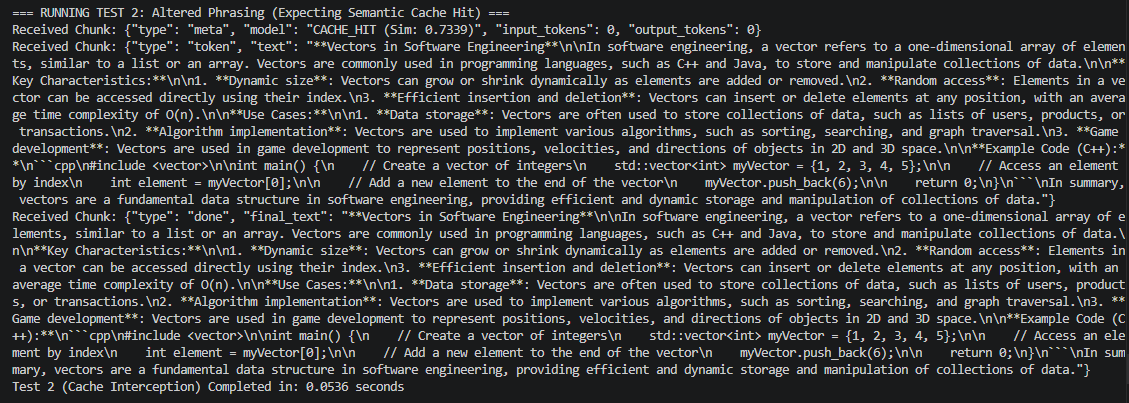

3. Cost Calculation

The cost tracker calculates the required tokens for both scenario 1 and 2, so we just need to call the endpoint to receive the report. The top request here is only 1 because we only call groq once (in scenario 1).

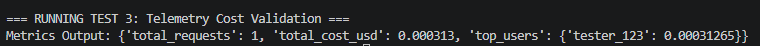

# Bye!

That's it for now! InshaAllah, I will explore and share more.